# B2: ML — FNDDS Meal Category Classification from Nutrients

**Input:** FNDDS.json (USDA FNDDS 2021–2023)

**Output:** fndds_ml_results.csv

## Methodology

This notebook asks: **can a model correctly identify a meal's food category using only its nutrient density profile — no names, no metadata?**

This is a harder problem than A7 (Foundation Foods) because:
- **18 classes** vs 7 — higher inter-class overlap
- **Mixed dishes dominate** — fast food, meals & entrees, and sandwiches are nutritionally very similar, making those confusions the most informative finding
- **5431 real composite meals** vs 369 raw whole ingredients — much higher within-group variance

### Food Group Mapping
FNDDS uses WWEIA (What We Eat In America) categories — a ~172-category system. We aggregate these into 18 interpretable broader groups based on the numeric WWEIA prefix (1xxx=dairy, 2xxx=proteins, 3xxx=mixed dishes, etc.).

### Evaluation philosophy
All metrics — confusion matrix, per-class accuracy, classification report, residuals — are computed from **out-of-fold cross-validation predictions** via `cross_val_predict`. Each sample is predicted by a model that never saw it during training. The full-data fit is used exclusively for SHAP.

In [1]:
import json
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score, cross_val_predict,
    learning_curve,
)
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)
import xgboost as xgb
import shap

In [2]:
WWEIA_TO_GROUP = {
    "1002": "dairy", "1004": "dairy", "1006": "dairy", "1008": "dairy",
    "1202": "dairy", "1204": "dairy", "1206": "dairy", "1208": "dairy",
    "1402": "dairy", "1602": "dairy", "1604": "dairy",
    "1820": "dairy", "1822": "dairy",
    "1902": "plant_based_milk", "1904": "plant_based_milk",
    "2002": "beef_pork_lamb", "2004": "beef_pork_lamb",
    "2006": "beef_pork_lamb", "2008": "beef_pork_lamb", "2010": "beef_pork_lamb",
    "2202": "poultry", "2204": "poultry", "2206": "poultry",
    "2402": "fish_shellfish", "2404": "fish_shellfish",
    "2502": "eggs",
    "2602": "processed_meat", "2604": "processed_meat",
    "2606": "processed_meat", "2608": "processed_meat",
    "2802": "legumes_nuts", "2804": "legumes_nuts", "2806": "legumes_nuts",
    "3002": "mixed_dishes", "3004": "mixed_dishes", "3006": "mixed_dishes",
    "3102": "mixed_dishes", "3104": "mixed_dishes",
    "3202": "mixed_dishes", "3204": "mixed_dishes", "3206": "mixed_dishes",
    "3208": "mixed_dishes",
    "3402": "mixed_dishes", "3404": "mixed_dishes", "3406": "mixed_dishes",
    "3502": "mixed_dishes", "3504": "mixed_dishes", "3506": "mixed_dishes",
    "3602": "fast_food", "3702": "fast_food", "3703": "fast_food",
    "3704": "fast_food", "3706": "fast_food", "3720": "fast_food",
    "3722": "fast_food", "3730": "fast_food", "3740": "fast_food",
    "3742": "fast_food", "3744": "fast_food",
    "3804": "soups", "3806": "soups", "3808": "soups",
    "4002": "grains_breads", "4004": "grains_breads",
    "4202": "grains_breads", "4204": "grains_breads",
    "4206": "grains_breads", "4208": "grains_breads",
    "4402": "grains_breads", "4404": "grains_breads",
    "4602": "grains_breads", "4604": "grains_breads",
    "4802": "grains_breads", "4804": "grains_breads",
    "5002": "snacks", "5004": "snacks", "5006": "snacks", "5008": "snacks",
    "5202": "snacks", "5204": "snacks", "5402": "snacks", "5404": "snacks",
    "5502": "sweets_desserts", "5504": "sweets_desserts", "5506": "sweets_desserts",
    "5702": "sweets_desserts", "5704": "sweets_desserts",
    "5802": "sweets_desserts", "5804": "sweets_desserts", "5806": "sweets_desserts",
    "6002": "fruits", "6004": "fruits", "6006": "fruits", "6008": "fruits",
    "6009": "fruits", "6011": "fruits", "6012": "fruits", "6014": "fruits",
    "6016": "fruits", "6018": "fruits", "6020": "fruits", "6022": "fruits",
    "6024": "fruits",
    "6402": "vegetables", "6404": "vegetables", "6406": "vegetables",
    "6407": "vegetables", "6409": "vegetables", "6410": "vegetables",
    "6411": "vegetables", "6412": "vegetables", "6413": "vegetables",
    "6414": "vegetables", "6416": "vegetables", "6418": "vegetables",
    "6420": "vegetables", "6430": "vegetables", "6432": "vegetables",
    "6489": "vegetables",
    "6802": "vegetables", "6804": "vegetables", "6806": "vegetables",
    "7002": "beverages", "7004": "beverages", "7006": "beverages", "7008": "beverages",
    "7102": "beverages", "7104": "beverages", "7106": "beverages",
    "7202": "beverages", "7204": "beverages", "7206": "beverages",
    "7208": "beverages", "7220": "beverages",
    "7302": "beverages", "7304": "beverages",
    "7702": "beverages", "7704": "beverages", "7802": "beverages", "7804": "beverages",
    "7502": "alcohol", "7504": "alcohol", "7506": "alcohol",
    "8002": "fats_condiments", "8004": "fats_condiments", "8006": "fats_condiments",
    "8008": "fats_condiments", "8010": "fats_condiments", "8012": "fats_condiments",
    "8402": "fats_condiments", "8404": "fats_condiments", "8406": "fats_condiments",
    "8408": "fats_condiments", "8410": "fats_condiments", "8412": "fats_condiments",
    "8802": "fats_condiments", "8804": "fats_condiments", "8806": "fats_condiments",
    "9002": "baby_formula", "9004": "baby_formula", "9006": "baby_formula",
    "9007": "baby_formula", "9008": "baby_formula", "9010": "baby_formula",
    "9012": "baby_formula", "9202": "baby_formula", "9204": "baby_formula",
    "9402": "baby_formula", "9404": "baby_formula", "9602": "baby_formula",
    "9802": "misc", "9999": "misc",
}

TARGET_NUTRIENT_IDS = [
    1008, 1003, 1004, 1005, 1079,
    1258, 1292, 1293, 1257, 1253,
    1063, 1235,
    1087, 1089, 1090, 1092, 1093, 1095,
    1162, 1106, 1114, 1178,
]

PALETTE = {
    "dairy":           "#3498db",
    "plant_based_milk":"#85c1e9",
    "beef_pork_lamb":  "#e74c3c",
    "poultry":         "#c0392b",
    "fish_shellfish":  "#1abc9c",
    "eggs":            "#f1c40f",
    "processed_meat":  "#e67e22",
    "legumes_nuts":    "#27ae60",
    "mixed_dishes":    "#8e44ad",
    "fast_food":       "#d35400",
    "soups":           "#2980b9",
    "grains_breads":   "#f39c12",
    "snacks":          "#e91e63",
    "sweets_desserts": "#ff69b4",
    "fruits":          "#2ecc71",
    "vegetables":      "#1e8449",
    "beverages":       "#34495e",
    "alcohol":         "#6c3483",
    "fats_condiments": "#95a5a6",
    "baby_formula":    "#aed6f1",
    "misc":            "#bdc3c7",
    "default":         "#95a5a6",
}

CV_FOLDS   = 5
RANDOM_SEED = 42

## 1. Load FNDDS JSON & Extract Nutrients

In [3]:
with open("FNDDS.json", encoding="utf-8") as f:
    raw = json.load(f)

foods = raw["SurveyFoods"]
print(f"Total foods in JSON: {len(foods)}")

Total foods in JSON: 5432


In [4]:
rows = []
for food in foods:
    nutrient_map = {}
    for fn in food.get("foodNutrients", []):
        nid = fn.get("nutrient", {}).get("id")
        if nid in TARGET_NUTRIENT_IDS:
            name = fn["nutrient"]["name"]
            nutrient_map[name] = fn.get("amount", np.nan)

    if not nutrient_map:
        continue

    attrs = {a.get("name"): a.get("value")
             for a in food.get("foodAttributes", [])
             if "name" in a}
    wweia_num = attrs.get("WWEIA Category number", "9999")
    group = WWEIA_TO_GROUP.get(str(wweia_num), "misc")

    row = {
        "fdcId":       food["fdcId"],
        "foodCode":    food["foodCode"],
        "description": food["description"],
        "wweia_num":   wweia_num,
        "wweia_desc":  attrs.get("WWEIA Category description", ""),
        "group":       group,
    }
    row.update(nutrient_map)
    rows.append(row)

df_raw = pd.DataFrame(rows)
print(f"Foods parsed: {len(df_raw)}")
print(f"\nGroup distribution:")
print(df_raw["group"].value_counts().to_string())

Foods parsed: 5431

Group distribution:
group
mixed_dishes        1123
vegetables           578
grains_breads        426
sweets_desserts      408
fast_food            400
beverages            359
fats_condiments      314
snacks               237
poultry              221
legumes_nuts         171
dairy                168
baby_formula         151
fish_shellfish       150
eggs                 147
fruits               120
beef_pork_lamb        96
misc                  94
alcohol               90
processed_meat        82
soups                 75
plant_based_milk      21


In [5]:
energy_col = "Energy"

mask_zero = df_raw[energy_col].fillna(0) == 0
df_raw.loc[mask_zero, energy_col] = (
    df_raw.loc[mask_zero, "Total lipid (fat)"].fillna(0) * 9 +
    df_raw.loc[mask_zero, "Protein"].fillna(0) * 4 +
    df_raw.loc[mask_zero, "Carbohydrate, by difference"].fillna(0) * 4
)

nutrient_cols = [c for c in df_raw.columns
                 if c not in ("fdcId", "foodCode", "description",
                              "wweia_num", "wweia_desc", "group")]

safe_energy  = df_raw[energy_col].replace(0, 0.1)
density_cols = []
for col in nutrient_cols:
    new_col = col.replace(", ", "_").replace(" ", "_") + "_per_100kcal"
    df_raw[new_col] = (df_raw[col] / safe_energy) * 100
    density_cols.append(new_col)

print(f"Nutrient density features: {len(density_cols)}")

Nutrient density features: 19


## 2. Feature Matrix & Label Filtering

Groups with fewer than 30 samples are dropped.

In [6]:
MIN_GROUP_SIZE = 30

group_counts   = df_raw["group"].value_counts()
valid_groups   = group_counts[group_counts >= MIN_GROUP_SIZE].index.tolist()
dropped_groups = group_counts[group_counts < MIN_GROUP_SIZE].index.tolist()

print(f"Keeping {len(valid_groups)} groups (n >= {MIN_GROUP_SIZE}):")
for g in valid_groups:
    print(f"  {g:25s}: {group_counts[g]:4d}")
print(f"\nDropped: {dropped_groups}")

df = df_raw[df_raw["group"].isin(valid_groups)].copy()
df = df.dropna(subset=density_cols).reset_index(drop=True)

le = LabelEncoder()
y  = le.fit_transform(df["group"])
class_names = le.classes_

scaler = StandardScaler()
X = scaler.fit_transform(df[density_cols])

short_names = [
    c.replace("_per_100kcal", "")
     .replace("_", " ")
     .replace("Fatty acids total ", "FA ")
     .replace("Vitamin ", "Vit ")
     .replace("total ascorbic acid", "")
     .strip()
    for c in density_cols
]

print(f"\nFinal dataset: {len(df)} foods, {len(valid_groups)} groups")
print(f"Feature matrix: {X.shape}")

Keeping 20 groups (n >= 30):
  mixed_dishes             : 1123
  vegetables               :  578
  grains_breads            :  426
  sweets_desserts          :  408
  fast_food                :  400
  beverages                :  359
  fats_condiments          :  314
  snacks                   :  237
  poultry                  :  221
  legumes_nuts             :  171
  dairy                    :  168
  baby_formula             :  151
  fish_shellfish           :  150
  eggs                     :  147
  fruits                   :  120
  beef_pork_lamb           :   96
  misc                     :   94
  alcohol                  :   90
  processed_meat           :   82
  soups                    :   75

Dropped: ['plant_based_milk']

Final dataset: 5410 foods, 20 groups
Feature matrix: (5410, 19)


## 3. Baseline

In [7]:
majority_class = df["group"].value_counts().idxmax()
majority_frac  = df["group"].value_counts(normalize=True).max()

print(f"Majority class: '{majority_class}' ({majority_frac*100:.1f}%)")
print(f"Baseline accuracy: {majority_frac*100:.1f}%")
print(f"Baseline macro-F1: ~{majority_frac / len(valid_groups):.3f}")

Majority class: 'mixed_dishes' (20.8%)
Baseline accuracy: 20.8%
Baseline macro-F1: ~0.010


## 4. Classification — CV Scoring & Out-of-Fold Evaluation

### Model training & CV scoring

In [8]:
CV_strat = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=1,
)
rf_scores = cross_val_score(rf, X, y, cv=CV_strat, scoring="f1_macro")
print(f"Random Forest  — macro F1: {rf_scores.mean():.3f} ± {rf_scores.std():.3f}")
print(f"  Per-fold: {[round(s,3) for s in rf_scores]}")

xgb_clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=RANDOM_SEED,
    n_jobs=1,
)
xgb_scores = cross_val_score(xgb_clf, X, y, cv=CV_strat, scoring="f1_macro")
print(f"XGBoost        — macro F1: {xgb_scores.mean():.3f} ± {xgb_scores.std():.3f}")
print(f"  Per-fold: {[round(s,3) for s in xgb_scores]}")
print(f"\nBaseline macro-F1: ~{majority_frac / len(valid_groups):.3f}")

Random Forest  — macro F1: 0.841 ± 0.013
  Per-fold: [np.float64(0.837), np.float64(0.838), np.float64(0.842), np.float64(0.823), np.float64(0.864)]
XGBoost        — macro F1: 0.838 ± 0.017
  Per-fold: [np.float64(0.845), np.float64(0.819), np.float64(0.846), np.float64(0.817), np.float64(0.861)]

Baseline macro-F1: ~0.010


### Out-of-fold predictions

`cross_val_predict` ensures every sample is evaluated by a model that never
saw it — all metrics below are unbiased estimates of generalisation performance.

In [9]:
print("Generating OOF predictions (Random Forest)...")
y_oof_rf  = cross_val_predict(rf,      X, y, cv=CV_strat)
print("Generating OOF predictions (XGBoost)...")
y_oof_xgb = cross_val_predict(xgb_clf, X, y, cv=CV_strat)

print("\n=== RANDOM FOREST — Out-of-fold classification report ===")
print(classification_report(y, y_oof_rf, target_names=class_names))

print("\n=== XGBOOST — Out-of-fold classification report ===")
print(classification_report(y, y_oof_xgb, target_names=class_names))

Generating OOF predictions (Random Forest)...
Generating OOF predictions (XGBoost)...

=== RANDOM FOREST — Out-of-fold classification report ===
                 precision    recall  f1-score   support

        alcohol       0.98      0.92      0.95        90
   baby_formula       0.96      0.77      0.86       151
 beef_pork_lamb       0.88      0.92      0.90        96
      beverages       0.84      0.90      0.87       359
          dairy       0.88      0.89      0.88       168
           eggs       0.95      0.97      0.96       147
      fast_food       0.91      0.91      0.91       400
fats_condiments       0.84      0.70      0.77       314
 fish_shellfish       0.90      0.93      0.91       150
         fruits       0.77      0.93      0.84       120
  grains_breads       0.85      0.91      0.88       426
   legumes_nuts       0.88      0.89      0.89       171
           misc       0.51      0.23      0.32        94
   mixed_dishes       0.88      0.88      0.88      1123

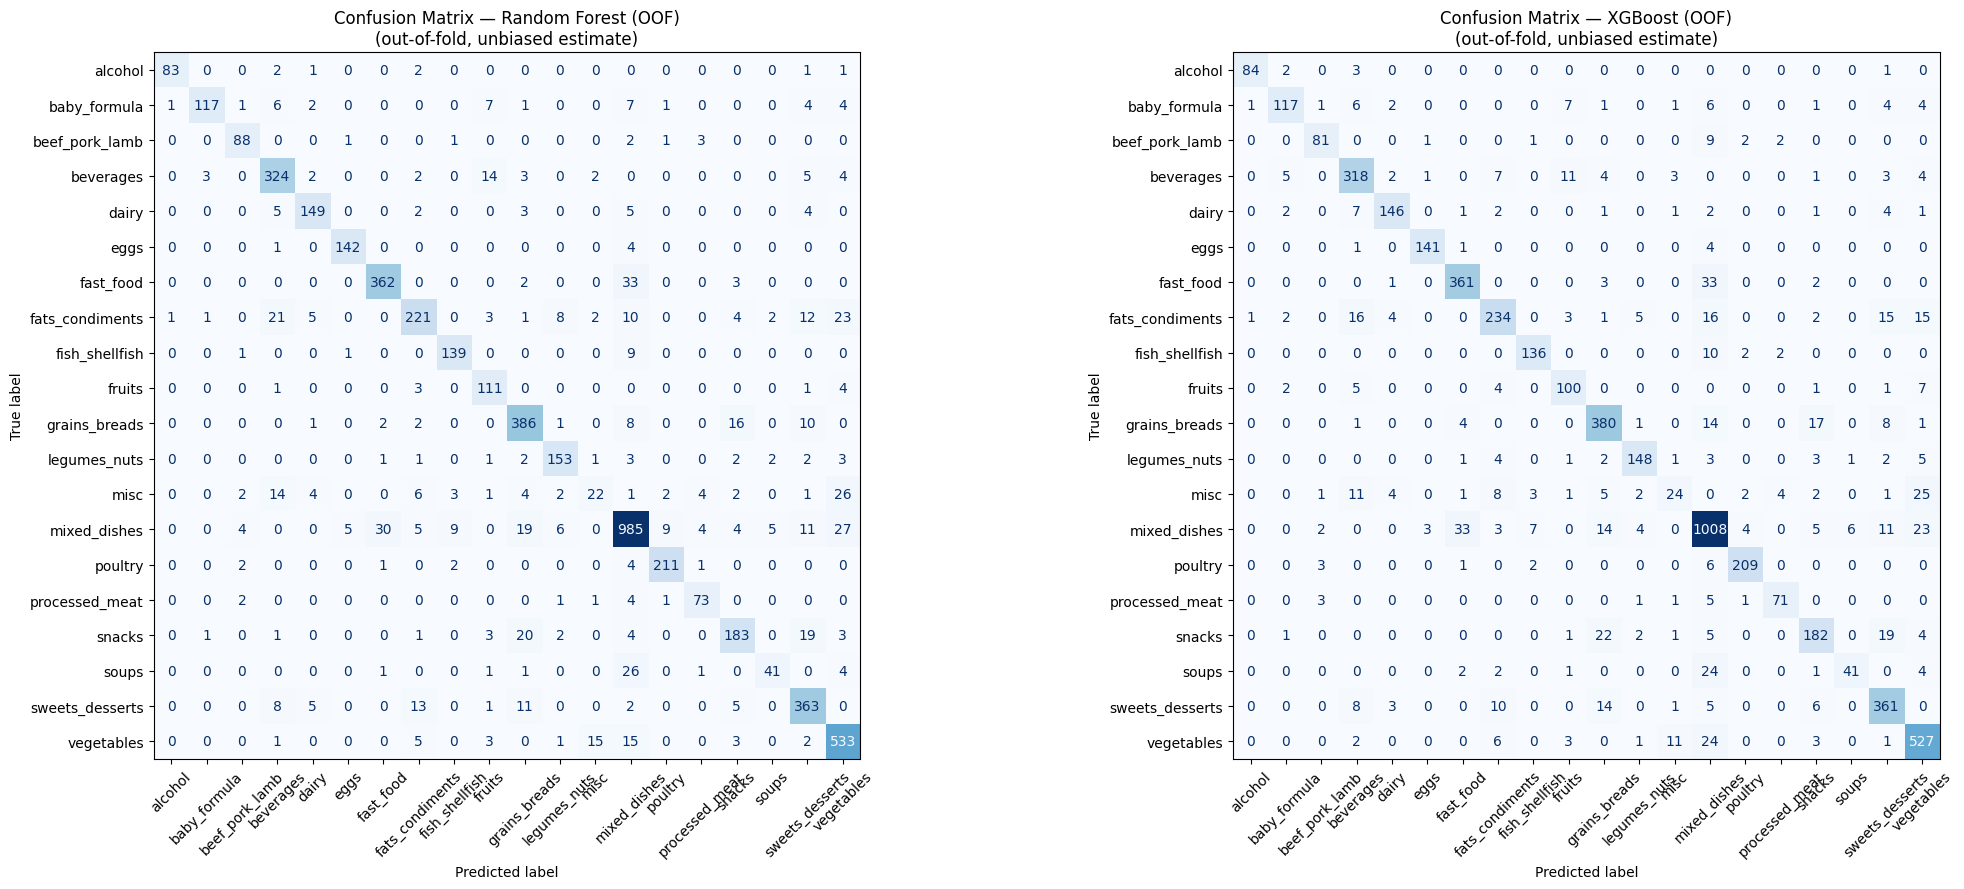

Per-class accuracy (Random Forest, OOF):
  alcohol                  :  83/ 90  (92%)
  baby_formula             : 117/151  (77%)
  beef_pork_lamb           :  88/ 96  (92%)
  beverages                : 324/359  (90%)
  dairy                    : 149/168  (89%)
  eggs                     : 142/147  (97%)
  fast_food                : 362/400  (90%)
  fats_condiments          : 221/314  (70%)
  fish_shellfish           : 139/150  (93%)
  fruits                   : 111/120  (92%)
  grains_breads            : 386/426  (91%)
  legumes_nuts             : 153/171  (89%)
  misc                     :  22/ 94  (23%)
  mixed_dishes             : 985/1123  (88%)
  poultry                  : 211/221  (95%)
  processed_meat           :  73/ 82  (89%)
  snacks                   : 183/237  (77%)
  soups                    :  41/ 75  (55%)
  sweets_desserts          : 363/408  (89%)
  vegetables               : 533/578  (92%)


In [10]:
# Side-by-side OOF confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(22, 9))

for ax, y_oof, title in zip(
    axes,
    [y_oof_rf, y_oof_xgb],
    ["Random Forest (OOF)", "XGBoost (OOF)"],
):
    cm_plot = confusion_matrix(y, y_oof)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_plot, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap="Blues", xticks_rotation=45)
    ax.set_title(f"Confusion Matrix — {title}\n(out-of-fold, unbiased estimate)")

plt.tight_layout()
plt.savefig("B2_confusion_matrix_oof.png", dpi=150, bbox_inches="tight")
plt.show()

# Use RF OOF CM for downstream analysis
cm_oof = confusion_matrix(y, y_oof_rf)

print("Per-class accuracy (Random Forest, OOF):")
for i, cls in enumerate(class_names):
    n_correct = cm_oof[i, i]
    n_total   = cm_oof[i].sum()
    print(f"  {cls:25s}: {n_correct:3d}/{n_total:3d}  ({100*n_correct/max(n_total,1):.0f}%)")

### Learning curves

A large gap between training and CV score = overfitting.
Converging curves = the model has learned generalizable structure.

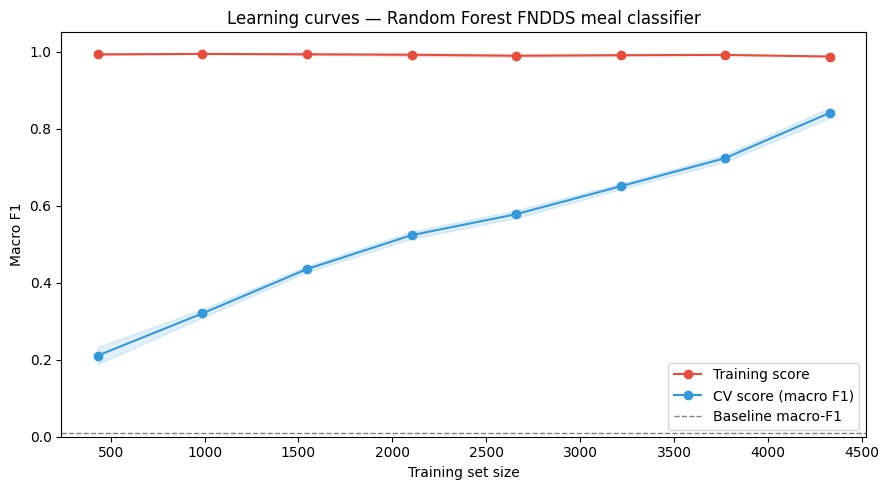

Final training score:  0.987 ± 0.001
Final CV score:        0.841 ± 0.013
Train-CV gap:          0.146  (some overfitting)


In [11]:
train_sizes, train_scores, cv_scores = learning_curve(
    rf, X, y,
    cv=CV_strat,
    scoring="f1_macro",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=1,
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
cv_mean    = cv_scores.mean(axis=1)
cv_std     = cv_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, "o-", color="#e74c3c", label="Training score")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color="#e74c3c")
ax.plot(train_sizes, cv_mean, "o-", color="#3498db", label="CV score (macro F1)")
ax.fill_between(train_sizes, cv_mean - cv_std, cv_mean + cv_std,
                alpha=0.15, color="#3498db")
ax.axhline(majority_frac / len(valid_groups), ls="--", color="grey",
           lw=1, label="Baseline macro-F1")
ax.set_xlabel("Training set size")
ax.set_ylabel("Macro F1")
ax.set_title("Learning curves — Random Forest FNDDS meal classifier")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig("B2_learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()

gap = train_mean[-1] - cv_mean[-1]
print(f"Final training score:  {train_mean[-1]:.3f} ± {train_std[-1]:.3f}")
print(f"Final CV score:        {cv_mean[-1]:.3f} ± {cv_std[-1]:.3f}")
print(f"Train-CV gap:          {gap:.3f}  ({'some overfitting' if gap > 0.1 else 'acceptable'})")

### OOF probability distribution

Per-class mean confidence reveals which meal categories are hardest to classify.

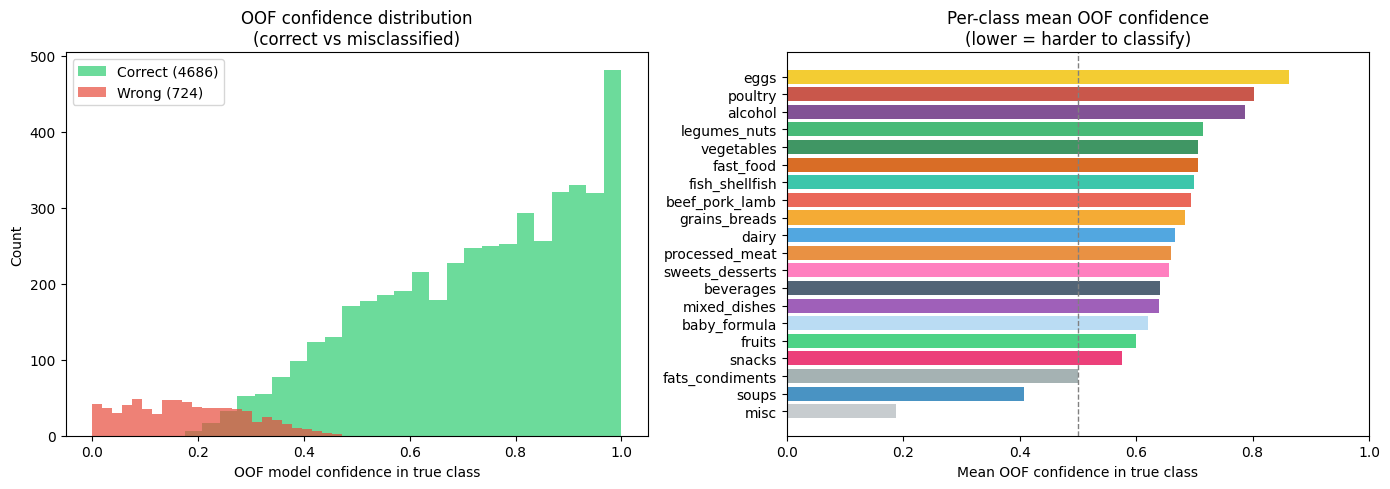

Overall mean OOF confidence: 0.654
Hardest class:  misc (0.187)
Easiest class:  eggs (0.862)


In [12]:
y_oof_proba = cross_val_predict(rf, X, y, cv=CV_strat, method="predict_proba")
true_class_proba = np.array([y_oof_proba[i, y[i]] for i in range(len(y))])
correct_mask = y_oof_rf == y

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(true_class_proba[correct_mask],  bins=25, alpha=0.7,
             color="#2ecc71", label=f"Correct ({correct_mask.sum()})")
axes[0].hist(true_class_proba[~correct_mask], bins=25, alpha=0.7,
             color="#e74c3c", label=f"Wrong ({(~correct_mask).sum()})")
axes[0].set_xlabel("OOF model confidence in true class")
axes[0].set_ylabel("Count")
axes[0].set_title("OOF confidence distribution\n(correct vs misclassified)")
axes[0].legend()

per_class_conf = {}
for i, cls in enumerate(class_names):
    mask_cls = y == i
    per_class_conf[cls] = true_class_proba[mask_cls].mean()

conf_series = pd.Series(per_class_conf).sort_values()
colors_bar  = [PALETTE.get(c, PALETTE["default"]) for c in conf_series.index]
axes[1].barh(conf_series.index, conf_series.values, color=colors_bar, alpha=0.85)
axes[1].axvline(0.5, ls="--", color="grey", lw=1)
axes[1].set_xlabel("Mean OOF confidence in true class")
axes[1].set_title("Per-class mean OOF confidence\n(lower = harder to classify)")
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.savefig("B2_oof_confidence.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Overall mean OOF confidence: {true_class_proba.mean():.3f}")
print(f"Hardest class:  {conf_series.idxmin()} ({conf_series.min():.3f})")
print(f"Easiest class:  {conf_series.idxmax()} ({conf_series.max():.3f})")

### Confusion hotspots (OOF)

Top 15 confusion pairs (OOF — true → predicted):
           true       predicted  count
      fast_food    mixed_dishes     33
   mixed_dishes       fast_food     30
   mixed_dishes      vegetables     27
           misc      vegetables     26
          soups    mixed_dishes     26
fats_condiments      vegetables     23
fats_condiments       beverages     21
         snacks   grains_breads     20
   mixed_dishes   grains_breads     19
         snacks sweets_desserts     19
  grains_breads          snacks     16
     vegetables            misc     15
     vegetables    mixed_dishes     15
      beverages          fruits     14
           misc       beverages     14


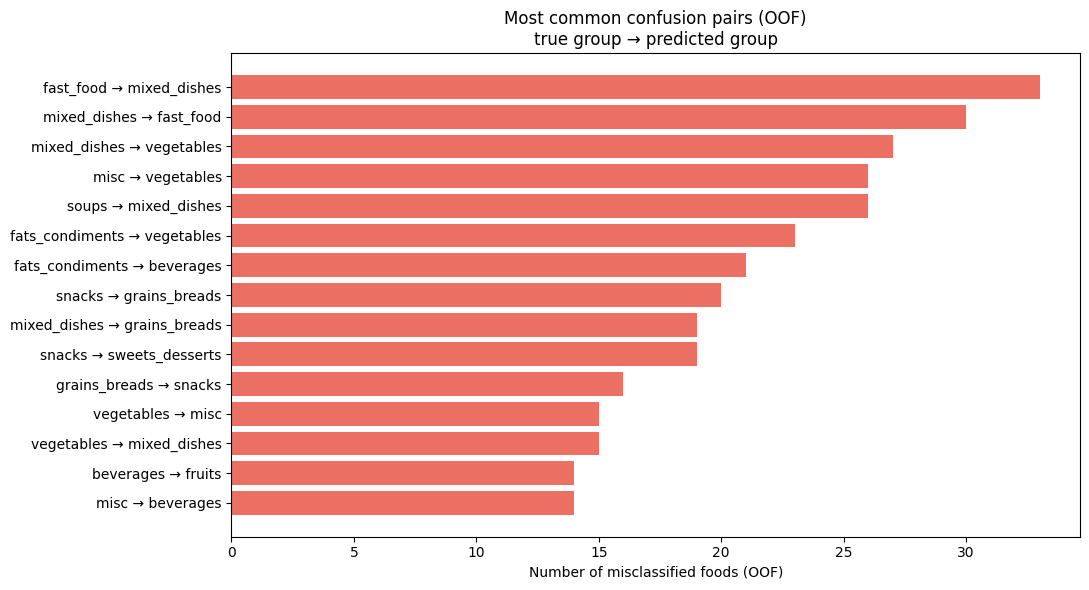

In [13]:
confusion_pairs = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm_oof[i, j] > 0:
            confusion_pairs.append({
                "true":      class_names[i],
                "predicted": class_names[j],
                "count":     cm_oof[i, j],
            })

conf_df = (
    pd.DataFrame(confusion_pairs)
    .sort_values("count", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

print("Top 15 confusion pairs (OOF — true → predicted):")
print(conf_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 6))
labels = [f"{r['true']} → {r['predicted']}" for _, r in conf_df.iterrows()]
ax.barh(labels[::-1], conf_df["count"][::-1], color="#e74c3c", alpha=0.8)
ax.set_xlabel("Number of misclassified foods (OOF)")
ax.set_title("Most common confusion pairs (OOF)\ntrue group → predicted group")
plt.tight_layout()
plt.savefig("B2_confusion_hotspots.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. SHAP — What Nutrients Define Each Meal Category?

Full-data fit used here for SHAP only. Clearly labelled.

Computing SHAP values (TreeExplainer on RF, full-data fit for attribution)...
SHAP array shape: (5410, 19, 20)


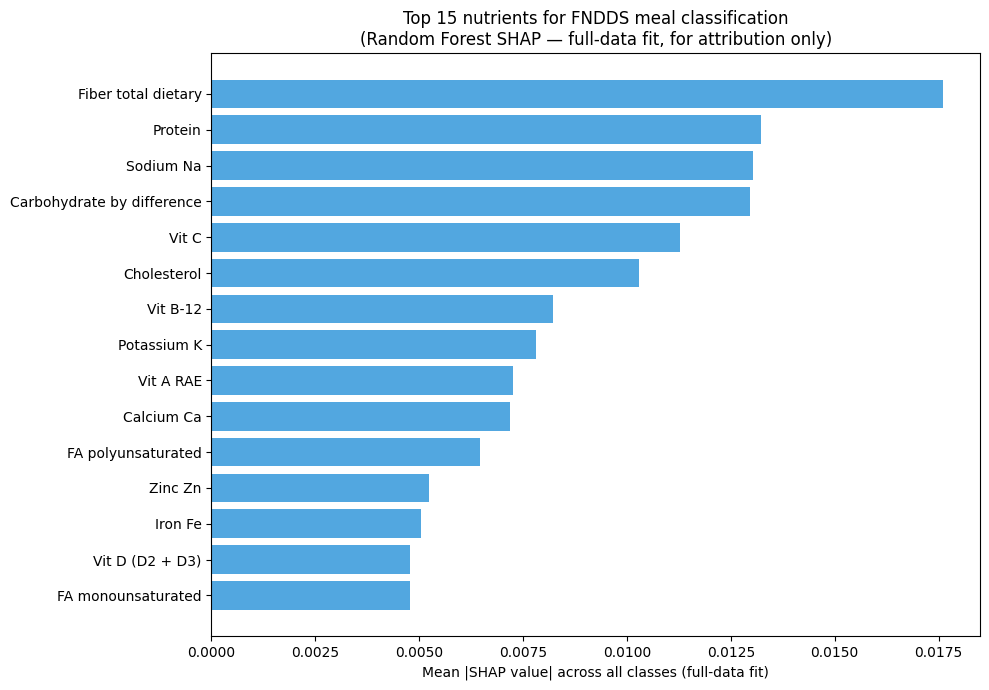


Top 10 most discriminative nutrients:
                   feature  mean_abs_shap
       Fiber total dietary       0.017618
                   Protein       0.013216
                 Sodium Na       0.013030
Carbohydrate by difference       0.012961
                     Vit C       0.011287
               Cholesterol       0.010288
                  Vit B-12       0.008218
               Potassium K       0.007805
                 Vit A RAE       0.007265
                Calcium Ca       0.007179


In [14]:
# Full-data fit for SHAP
rf.fit(X, y)
xgb_clf.fit(X, y)

print("Computing SHAP values (TreeExplainer on RF, full-data fit for attribution)...")
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

if isinstance(shap_values, list):
    shap_3d = np.stack(shap_values, axis=2)
else:
    shap_3d = shap_values

print(f"SHAP array shape: {shap_3d.shape}")

mean_abs_shap = np.abs(shap_3d).mean(axis=(0, 2))
importance_df = pd.DataFrame({
    "feature":       short_names,
    "mean_abs_shap": mean_abs_shap,
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 7))
top_n   = 15
top_imp = importance_df.head(top_n)
ax.barh(top_imp["feature"][::-1], top_imp["mean_abs_shap"][::-1],
        color="#3498db", alpha=0.85)
ax.set_xlabel("Mean |SHAP value| across all classes (full-data fit)")
ax.set_title(f"Top {top_n} nutrients for FNDDS meal classification\n"
             "(Random Forest SHAP — full-data fit, for attribution only)")
plt.tight_layout()
plt.savefig("B2_shap_global_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 10 most discriminative nutrients:")
print(importance_df.head(10)[["feature", "mean_abs_shap"]].to_string(index=False))

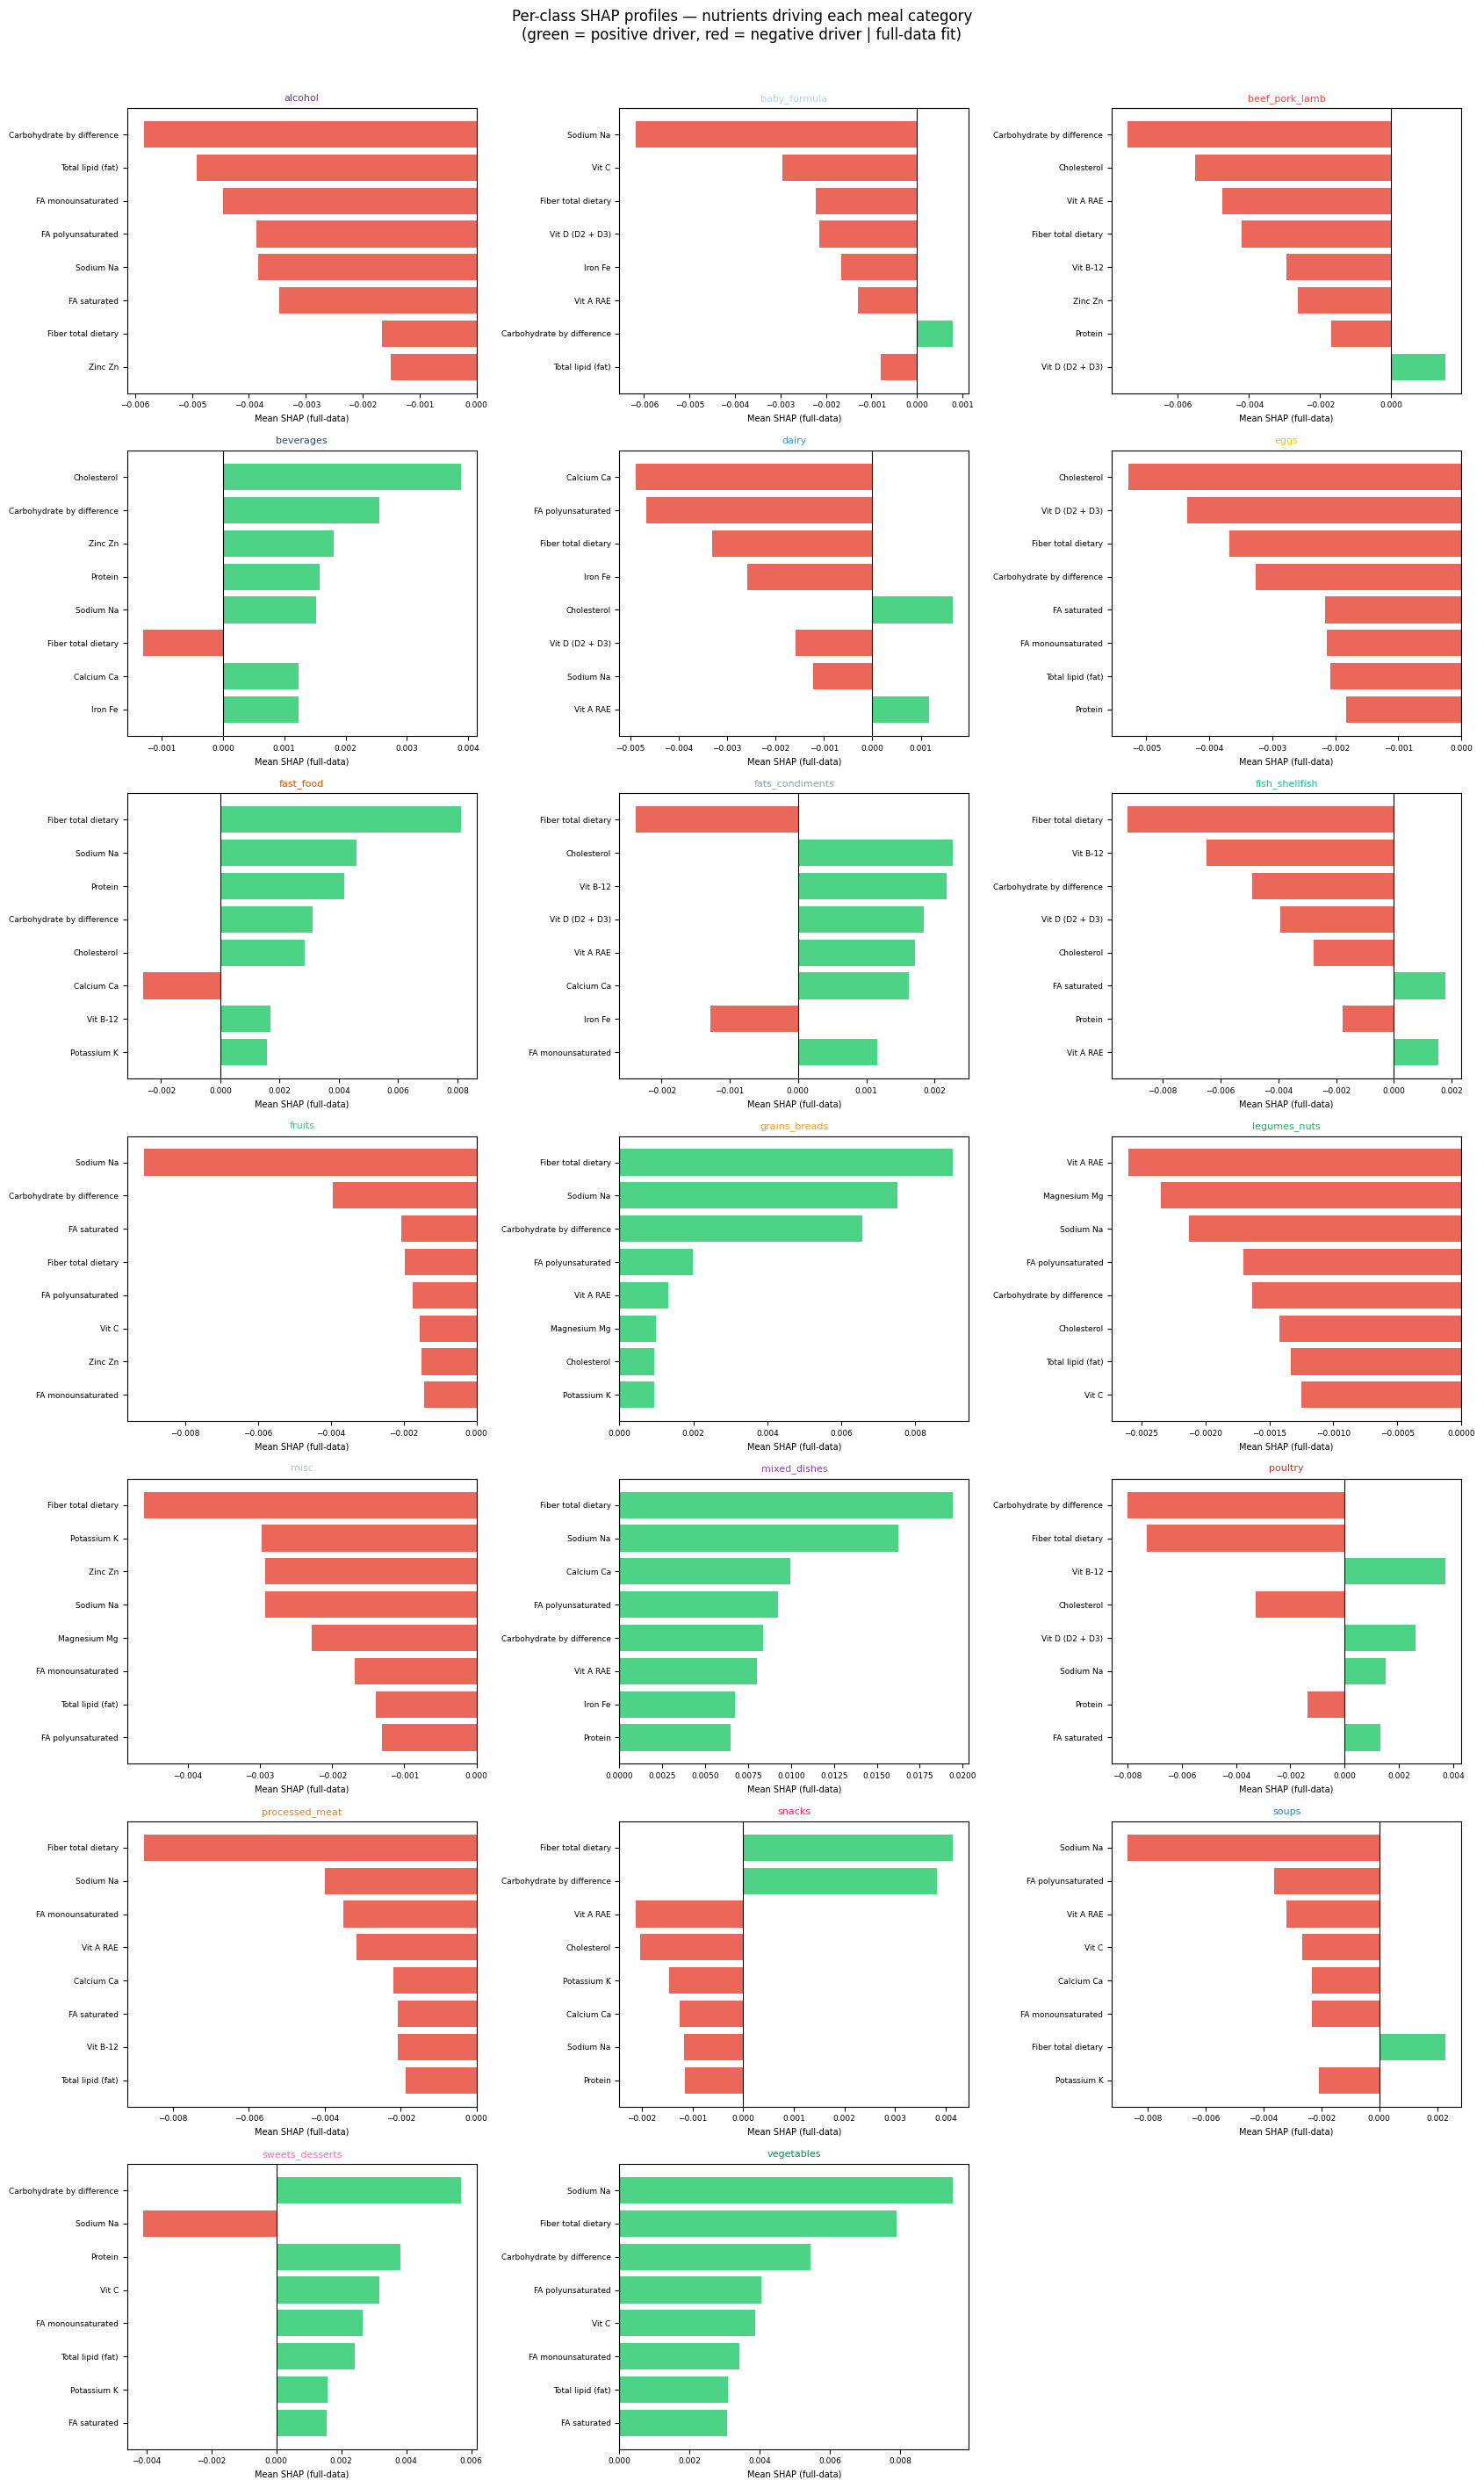

In [15]:
n_classes = len(class_names)
n_cols = 3
n_rows = (n_classes + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(17, 4 * n_rows))
axes_flat = axes.flat

for i, cls in enumerate(class_names):
    ax = axes_flat[i]
    class_shap  = shap_3d[:, :, i].mean(axis=0)
    idx_sorted  = np.argsort(np.abs(class_shap))[::-1][:8]
    feat_labels = [short_names[j] for j in idx_sorted]
    values      = [class_shap[j]  for j in idx_sorted]
    colors      = ["#2ecc71" if v > 0 else "#e74c3c" for v in values]
    ax.barh(feat_labels[::-1], values[::-1], color=colors[::-1], alpha=0.85)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(cls, fontsize=8, color=PALETTE.get(cls, PALETTE["default"]))
    ax.set_xlabel("Mean SHAP (full-data)", fontsize=7)
    ax.tick_params(labelsize=6.5)

for j in range(i + 1, n_rows * n_cols):
    axes_flat[j].set_visible(False)

plt.suptitle("Per-class SHAP profiles — nutrients driving each meal category\n"
             "(green = positive driver, red = negative driver | full-data fit)", y=1.01)
plt.tight_layout()
plt.savefig("B2_shap_per_class.png", dpi=150, bbox_inches="tight")
plt.show()

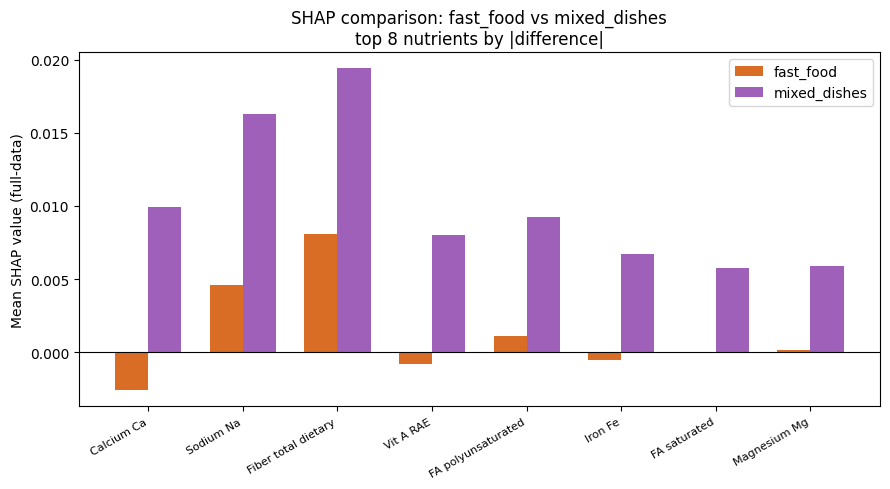

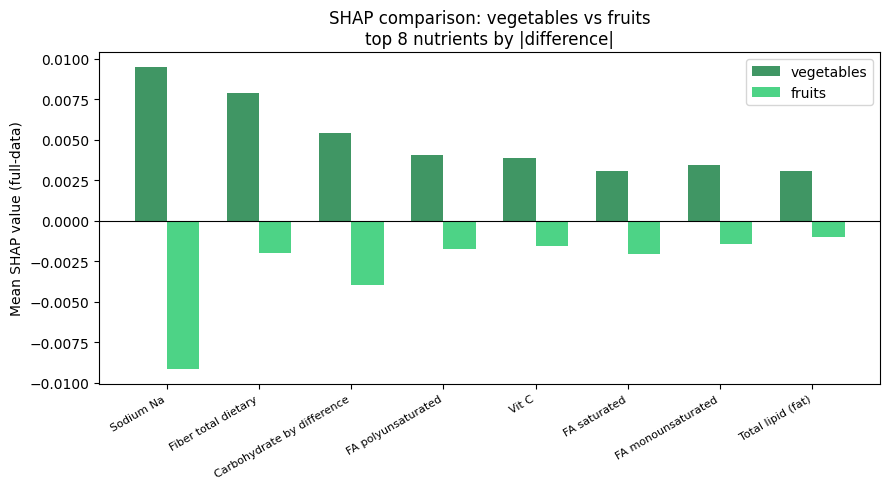

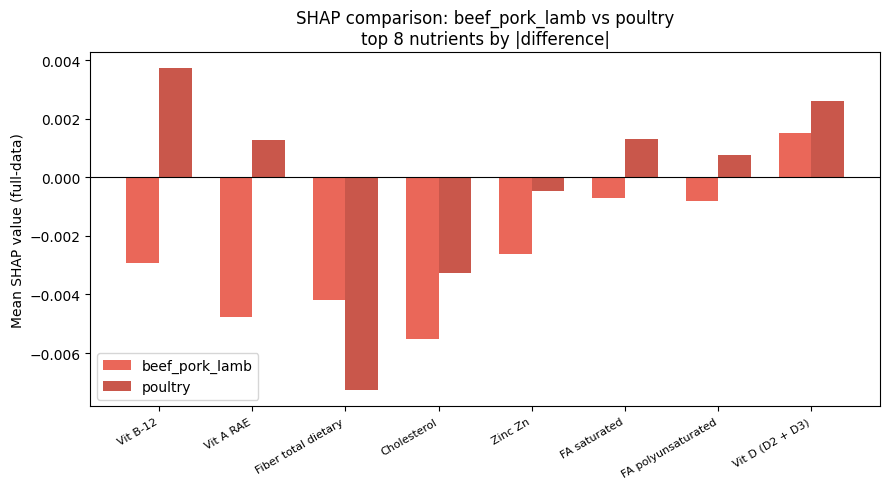

In [16]:
# Pairwise SHAP comparisons for the most interesting pairs
pairs = [
    ("fast_food",    "mixed_dishes"),
    ("vegetables",   "fruits"),
    ("beef_pork_lamb", "poultry"),
]

for grp_a, grp_b in pairs:
    if grp_a not in list(class_names) or grp_b not in list(class_names):
        print(f"Skipping {grp_a} vs {grp_b} — one or both not in valid groups")
        continue
    idx_a = list(class_names).index(grp_a)
    idx_b = list(class_names).index(grp_b)

    shap_a = shap_3d[:, :, idx_a].mean(axis=0)
    shap_b = shap_3d[:, :, idx_b].mean(axis=0)

    diff  = np.abs(shap_a - shap_b)
    top8  = np.argsort(diff)[::-1][:8]

    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(8)
    w = 0.35
    ax.bar(x - w/2, shap_a[top8], width=w,
           color=PALETTE.get(grp_a, "#3498db"), alpha=0.85, label=grp_a)
    ax.bar(x + w/2, shap_b[top8], width=w,
           color=PALETTE.get(grp_b, "#e74c3c"), alpha=0.85, label=grp_b)
    ax.set_xticks(x)
    ax.set_xticklabels([short_names[j] for j in top8],
                       rotation=30, ha="right", fontsize=8)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel("Mean SHAP value (full-data)")
    ax.set_title(f"SHAP comparison: {grp_a} vs {grp_b}\n"
                 f"top 8 nutrients by |difference|")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"B2_shap_compare_{grp_a}_vs_{grp_b}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 6. Nutritional Outliers — Meals the Model Gets Wrong (OOF)

OOF probabilities used throughout — methodologically correct.

In [17]:
df = df.copy()
df["predicted_group_oof"]  = le.inverse_transform(y_oof_rf)
df["true_group_prob_oof"]  = true_class_proba
df["predicted_group_prob"] = y_oof_proba.max(axis=1)
df["correctly_classified"] = y_oof_rf == y

n_wrong = (~df["correctly_classified"]).sum()
print(f"Misclassified (OOF): {n_wrong} / {len(df)}  ({100*n_wrong/len(df):.1f}%)")

outliers = (
    df[~df["correctly_classified"]]
    .sort_values("true_group_prob_oof")
    .head(30)
)

cols_out = ["description", "group", "predicted_group_oof",
            "true_group_prob_oof", "predicted_group_prob"]
print(f"\nTop 30 most surprising misclassifications (OOF):")
print(outliers[cols_out].to_string(index=False))

Misclassified (OOF): 724 / 5410  (13.4%)

Top 30 most surprising misclassifications (OOF):
                                                           description           group predicted_group_oof  true_group_prob_oof  predicted_group_prob
                                  Industrial oil as ingredient in food            misc     fats_condiments             0.000000              0.995870
                                             Frozen dessert, non-dairy    legumes_nuts     sweets_desserts             0.000000              0.440807
                                      Soup, ramen noodles, water added           soups       grains_breads             0.000000              0.325591
                                                           Soup, fruit           soups              fruits             0.000000              0.448263
                                                           Water, baby    baby_formula             alcohol             0.000984              0.435284
         

In [22]:
#additioanll cell, ommited because of length, but it is just visualization of outliers in PCA space, with annotations for the most surprising misclassifications
'''
pca2 = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca = pca2.fit_transform(X)

df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

# Refresh outliers to include PCA columns
outliers = (
    df[~df["correctly_classified"]]
    .sort_values("true_group_prob_oof")
    .head(30)
)

fig, ax = plt.subplots(figsize=(14, 9))

for grp, grp_df in df.groupby("group"):
    ax.scatter(grp_df["PCA1"], grp_df["PCA2"],
               color=PALETTE.get(grp, PALETTE["default"]),
               alpha=0.22, s=15, edgecolors="none", label=grp)

mis = df[~df["correctly_classified"]]
ax.scatter(mis["PCA1"], mis["PCA2"],
           facecolors="none", edgecolors="black", s=60, linewidths=1.2,
           zorder=4, label="Misclassified (OOF)")

for _, r in outliers.head(20).iterrows():
    ax.annotate(
        f"{r['description'][:24]}\n→{r['predicted_group_oof'][:14]}",
        (r["PCA1"], r["PCA2"]),
        fontsize=5, xytext=(6, 4), textcoords="offset points", zorder=5,
    )

ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("PCA — misclassified meals (OOF predictions)\n"
             "Black circle = wrong OOF prediction  |  label shows predicted group")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=6.5, ncol=1)
plt.tight_layout()
plt.savefig("B2_outliers_pca.png", dpi=150, bbox_inches="tight")
plt.show()
'''

'\npca2 = PCA(n_components=2, random_state=RANDOM_SEED)\nX_pca = pca2.fit_transform(X)\n\ndf["PCA1"] = X_pca[:, 0]\ndf["PCA2"] = X_pca[:, 1]\n\n# Refresh outliers to include PCA columns\noutliers = (\n    df[~df["correctly_classified"]]\n    .sort_values("true_group_prob_oof")\n    .head(30)\n)\n\nfig, ax = plt.subplots(figsize=(14, 9))\n\nfor grp, grp_df in df.groupby("group"):\n    ax.scatter(grp_df["PCA1"], grp_df["PCA2"],\n               color=PALETTE.get(grp, PALETTE["default"]),\n               alpha=0.22, s=15, edgecolors="none", label=grp)\n\nmis = df[~df["correctly_classified"]]\nax.scatter(mis["PCA1"], mis["PCA2"],\n           facecolors="none", edgecolors="black", s=60, linewidths=1.2,\n           zorder=4, label="Misclassified (OOF)")\n\nfor _, r in outliers.head(20).iterrows():\n    ax.annotate(\n        f"{r[\'description\'][:24]}\n→{r[\'predicted_group_oof\'][:14]}",\n        (r["PCA1"], r["PCA2"]),\n        fontsize=5, xytext=(6, 4), textcoords="offset points", zorder=5

In [19]:
# Deep dive: 3 most surprising OOF misclassifications
compare_density = [c for c in density_cols if any(
    k in c for k in ["Protein", "lipid", "Carbohydrate", "Fiber",
                     "saturated", "Calcium", "Sodium", "Cholesterol"]
)][:8]
compare_short = ["Protein", "Fat", "Carbs", "Fiber",
                 "Sat.Fat", "Calcium", "Sodium", "Chol"][:len(compare_density)]

print("=== Deep dive: 3 most surprising misclassifications (OOF) ===\n")
for _, row in outliers.head(3).iterrows():
    true_grp  = row["group"]
    pred_grp  = row["predicted_group_oof"]
    true_mean = df[df["group"] == true_grp][compare_density].mean()
    pred_mean = df[df["group"] == pred_grp][compare_density].mean()
    food_vals = df[df["description"] == row["description"]][compare_density]
    if food_vals.empty:
        continue
    food_vals = food_vals.iloc[0]

    print(f"Meal:            {row['description']}")
    print(f"True group:      {true_grp}  (OOF confidence: {row['true_group_prob_oof']:.2%})")
    print(f"Predicted group: {pred_grp}  (OOF confidence: {row['predicted_group_prob']:.2%})")
    print(f"{'Nutrient':12s}  {'This meal':>10s}  {'True grp avg':>13s}  {'Pred grp avg':>13s}")
    print("-" * 55)
    for col, short in zip(compare_density, compare_short):
        print(f"{short:12s}  {food_vals[col]:>10.2f}  {true_mean[col]:>13.2f}  {pred_mean[col]:>13.2f}")
    print()

=== Deep dive: 3 most surprising misclassifications (OOF) ===

Meal:            Industrial oil as ingredient in food
True group:      misc  (OOF confidence: 0.00%)
Predicted group: fats_condiments  (OOF confidence: 99.59%)
Nutrient       This meal   True grp avg   Pred grp avg
-------------------------------------------------------
Protein             0.00           6.46           1.89
Fat                11.21           2.20           5.13
Carbs               0.00          14.90          12.21
Fiber               0.00           2.83           1.10
Sat.Fat             0.00          96.34          34.43
Calcium             0.00         162.50         806.09
Sodium              0.00           7.07           6.19
Chol                3.67           0.68           1.53

Meal:            Frozen dessert, non-dairy
True group:      legumes_nuts  (OOF confidence: 0.00%)
Predicted group: sweets_desserts  (OOF confidence: 44.08%)
Nutrient       This meal   True grp avg   Pred grp avg
-------------

## 7. Summary & Key Findings

In [20]:
print("=" * 70)
print("B2 — SUMMARY OF FINDINGS")
print("=" * 70)

top5 = "\n".join(
    f"    {i+1}. {r['feature']}"
    for i, r in importance_df.head(5).iterrows()
)
top_conf = conf_df.iloc[0]

print(f"""
Dataset
────────
  Total FNDDS foods:  {len(df_raw):,}
  After filtering:    {len(df):,} foods, {len(valid_groups)} groups
  Dropped groups:     {dropped_groups}

Classification Performance (all OOF / unbiased)
─────────────────────────────────────────────────
  Baseline macro-F1:         ~{majority_frac / len(valid_groups):.3f}
  Random Forest macro-F1:     {rf_scores.mean():.3f} ± {rf_scores.std():.3f}
  XGBoost macro-F1:           {xgb_scores.mean():.3f} ± {xgb_scores.std():.3f}
  Train-CV gap (RF):           {train_mean[-1] - cv_mean[-1]:.3f}

  OOF misclassified:   {n_wrong} / {len(df)}  ({100*n_wrong/len(df):.1f}%)
  Hardest class:       {conf_series.idxmin()} (mean OOF confidence {conf_series.min():.3f})
  Most confused pair:  {top_conf['true']} → {top_conf['predicted']} ({int(top_conf['count'])} foods)

Most Discriminative Nutrients (SHAP top 5, full-data)
───────────────────────────────────────────────────────
{top5}

Most surprising OOF misclassification:
  {outliers.iloc[0]['description'][:60]}
  true: {outliers.iloc[0]['group']} → predicted: {outliers.iloc[0]['predicted_group_oof']}
""")

B2 — SUMMARY OF FINDINGS

Dataset
────────
  Total FNDDS foods:  5,431
  After filtering:    5,410 foods, 20 groups
  Dropped groups:     ['plant_based_milk']

Classification Performance (all OOF / unbiased)
─────────────────────────────────────────────────
  Baseline macro-F1:         ~0.010
  Random Forest macro-F1:     0.841 ± 0.013
  XGBoost macro-F1:           0.838 ± 0.017
  Train-CV gap (RF):           0.146

  OOF misclassified:   724 / 5410  (13.4%)
  Hardest class:       misc (mean OOF confidence 0.187)
  Most confused pair:  fast_food → mixed_dishes (33 foods)

Most Discriminative Nutrients (SHAP top 5, full-data)
───────────────────────────────────────────────────────
    1. Fiber total dietary
    2. Protein
    3. Sodium Na
    4. Carbohydrate by difference
    5. Vit C

Most surprising OOF misclassification:
  Industrial oil as ingredient in food
  true: misc → predicted: fats_condiments



## 8. Save

In [21]:
df_out = df[[
    "fdcId", "foodCode", "description", "wweia_num", "wweia_desc",
    "group", "predicted_group_oof", "true_group_prob_oof",
    "predicted_group_prob", "correctly_classified", "PCA1", "PCA2",
]].copy()

df_out.to_csv("fndds_ml_results.csv", index=False)
print("Saved: fndds_ml_results.csv")
print("Shape:", df_out.shape)

print("\nPlots saved:")
for fname in [
    "B2_confusion_matrix_oof.png",
    "B2_learning_curve.png",
    "B2_oof_confidence.png",
    "B2_confusion_hotspots.png",
    "B2_shap_global_importance.png",
    "B2_shap_per_class.png",
    "B2_shap_compare_fast_food_vs_mixed_dishes.png",
    "B2_shap_compare_vegetables_vs_fruits.png",
    "B2_shap_compare_beef_pork_lamb_vs_poultry.png",
    "B2_outliers_pca.png",
]:
    print(f"  {fname}")

Saved: fndds_ml_results.csv
Shape: (5410, 12)

Plots saved:
  B2_confusion_matrix_oof.png
  B2_learning_curve.png
  B2_oof_confidence.png
  B2_confusion_hotspots.png
  B2_shap_global_importance.png
  B2_shap_per_class.png
  B2_shap_compare_fast_food_vs_mixed_dishes.png
  B2_shap_compare_vegetables_vs_fruits.png
  B2_shap_compare_beef_pork_lamb_vs_poultry.png
  B2_outliers_pca.png
